## 0. Setup

In [8]:
INDIA_PROJECTED_CRS = "24378"

In [9]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# general
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm

from os import listdir

# for plotting and coloring
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

# for handling S2 cells and downloading VIDA data
import boto3
from s2cell.s2cell import lat_lon_to_cell_id
import s2sphere
from shapely.geometry import Polygon

gpd.options.io_engine = "pyogrio"

In [11]:
from gridsample.utils import create_ids, create_gmap_links, save_shapefiles
# from gridsample.mapping import create_interactive_map

In [12]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"
CLEANED_DATA_DIR = DATA_DIR / "02. Intermediate Outputs"
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs" / "pilot v2"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

In [13]:
def generate_colormap(N):
    arr = np.arange(N) / N
    N_up = int(math.ceil(N / 7) * 7)
    arr.resize(N_up)
    arr = arr.reshape(7, N_up // 7).T.reshape(-1)
    ret = matplotlib.cm.hsv(arr)
    n = ret[:, 3].size
    a = n // 2
    b = n - a

    # Create arrays of exactly matching sizes
    for i in range(3):
        ret[0:a, i] *= np.linspace(0.2, 1, a)
    ret[a:, 3] *= np.linspace(1, 0.3, b)

    return ret[:N]  # Return only the requested number of colors

## 1. Load Pilot Boundaries

In [44]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
gdf = gpd.read_file(RAW_DATA_DIR / "99. Side Quest Data" / "Phase 2 circles.geojson")
gdf.to_crs(4326, inplace=True)

# Check there are 30 shapes
len(gdf)

27

#### Add unique ID column

In [45]:
gdf["Unique Shape ID"] = create_ids(len(gdf), "SHAPE_")
gdf

,geometry,Unique Shape ID
0,"POLYGON ((77.27334 28.68229, 77.27169 28.68222...",SHAPE_01
1,"POLYGON ((77.29870 28.65801, 77.29611 28.65790...",SHAPE_02
2,"POLYGON ((77.32157 28.70007, 77.31905 28.69996...",SHAPE_03
3,"POLYGON ((76.64972 12.34781, 76.64921 12.34779...",SHAPE_04
4,"POLYGON ((76.66065 12.34129, 76.66022 12.34127...",SHAPE_05
5,"POLYGON ((76.66725 12.34861, 76.66679 12.34859...",SHAPE_06
6,"POLYGON ((75.77146 11.30785, 75.77080 11.30782...",SHAPE_07
7,"POLYGON ((75.78833 11.30621, 75.78748 11.30617...",SHAPE_08
8,"POLYGON ((75.77565 11.29485, 75.77501 11.29482...",SHAPE_09
9,"POLYGON ((75.16238 30.81770, 75.16171 30.81768...",SHAPE_10


## 2. Download rooftops

### Functions

#### S2 cell shapes

In [46]:
def s2_cell_id_to_shape(s2_cell_id):
    """
    Convert an S2 cell ID to a shapely polygon.

    Parameters:
    - s2_cell_id (int): The S2 cell ID

    Returns:
    - shapely.geometry.Polygon: Polygon representing the S2 cell
    """
    # Convert string to int if necessary
    if isinstance(s2_cell_id, str):
        s2_cell_id = int(s2_cell_id)

    # Create an S2 cell from the ID
    cell = s2sphere.CellId(s2_cell_id)
    cell = s2sphere.Cell(cell)

    # Extract the vertices of the cell
    vertices = []
    for i in range(4):
        vertex = cell.get_vertex(i)
        lat_lng = s2sphere.LatLng.from_point(vertex)
        vertices.append((lat_lng.lng().degrees, lat_lng.lat().degrees))

    # Close the polygon by repeating the first vertex
    vertices.append(vertices[0])

    # Create a shapely polygon
    return Polygon(vertices)


def s2_cell_ids_to_shapes_gdf(s2_cell_ids):
    """
    Convert a list of S2 cell IDs to a GeoDataFrame with polygon geometries.

    Parameters:
    - s2_cell_ids (list): List of S2 cell IDs

    Returns:
    - geopandas.GeoDataFrame: GeoDataFrame with S2 cells as polygons
    """
    geometries = []
    for s2_id in s2_cell_ids:
        polygon = s2_cell_id_to_shape(s2_id)
        geometries.append(polygon)

    return gpd.GeoDataFrame(
        {"s2_cell_id": s2_cell_ids, "geometry": geometries}, crs="EPSG:4326"
    )

#### Find IDs of overlapping S2 cells

In [47]:
def get_s2_cell_ids_from_points(points, level=6) -> list[int]:
    """
    Get S2 cell IDs for the given points at the specified level.
    """
    # check if crs is set to WGS84 (EPSG:4326)
    if points.crs is None or points.crs.to_string() != "EPSG:4326":
        raise ValueError("Points GeoDataFrame must be in WGS84 (EPSG:4326) CRS.")

    # convert points to S2 cell IDs
    s2_cell_id_list = points.geometry.apply(
        lambda geom: lat_lon_to_cell_id(geom.y, geom.x, level)
    )
    s2_cell_ids = s2_cell_id_list.unique().tolist()

    return s2_cell_ids


def get_s2_cell_ids(gdf, level=6) -> list[int]:
    """
    Get S2 cell IDs of S2 cells that overlap the given GeoDataFrame at the specified level.

    Iteratively checks if any area is not covered by an S2 cell and continues until all areas are covered.

    Parameters:
    - gdf: GeoDataFrame in WGS84 (EPSG:4326) CRS
    - level: int

    Returns:
    - list[int]: List of S2 cell IDs
    """

    # check if crs is set to WGS84 (EPSG:4326)
    if gdf.crs is None or gdf.crs.to_string() != "EPSG:4326":
        raise ValueError("GeoDataFrame must be in WGS84 (EPSG:4326) CRS.")

    # generate initial S2 cell IDs from the GeoDataFrame centroids
    points = gdf.geometry.centroid.to_frame(name="geometry")
    s2_cell_ids = get_s2_cell_ids_from_points(points, level=level)

    # get initial S2 cell shapes and check for full coverage
    s2_cell_shapes = s2_cell_ids_to_shapes_gdf(s2_cell_ids)
    leftover_shapes = gdf.difference(s2_cell_shapes.unary_union)
    leftover_shapes = leftover_shapes[~leftover_shapes.is_empty]

    print(f"Shapes with spillover after round 1: {len(leftover_shapes)}")

    step = 2
    while len(leftover_shapes) > 0:
        # get new s2 cell IDs from the leftover shapes
        points_new = leftover_shapes.geometry.centroid.to_frame(name="geometry")
        s2_cell_ids_new = get_s2_cell_ids_from_points(points_new, level=level)

        # get new s2 cell shapes
        s2_cell_shapes = s2_cell_ids_to_shapes_gdf(s2_cell_ids_new)
        leftover_shapes = leftover_shapes.difference(s2_cell_shapes.unary_union)
        leftover_shapes = leftover_shapes[~leftover_shapes.is_empty]

        # add new s2 cell IDs to the existing list
        s2_cell_ids = s2_cell_ids + s2_cell_ids_new

        print(f"Shapes with spillover after round {step}: {len(leftover_shapes)}")
        step += 1

    return s2_cell_ids

#### Auto-download rooftop data by S2 cell ID

In [48]:
def download_VIDA_rooftops_data_by_s2_single(
    s2_cell_id: int, country_iso_code: str, target_data_dir: Path
) -> None:
    """
    Download S2 rooftops data for a given S2 cell ID from the VIDA S3 bucket. URL:
    https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/
    """

    s2_rooftops_path = target_data_dir / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print(f"File {s2_cell_id} already exists.")
    else:
        print(f"Downloading file for S2 cell ID: {s2_cell_id}")
        s2_rooftops_path.parent.mkdir(parents=True, exist_ok=True)
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        try:
            s3.download_file(
                "vida",
                f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso={country_iso_code}/{s2_cell_id}.parquet",
                str(s2_rooftops_path),
            )
            print(f"File {s2_cell_id} downloaded.")
        except Exception as e:
            raise RuntimeError(
                f"Failed to download file for S2 cell ID {s2_cell_id}: {e}"
            )


def download_VIDA_rooftops_data_by_s2(
    s2_cell_ids: list[int], country_iso_code: str, target_data_dir: Path
) -> None:
    """
    Download S2 rooftops data for multiple S2 cell IDs

    Parameters:
    - s2_cell_ids: list of S2 cell IDs
    - country_iso_code: ISO code of the country (e.g., "IND" for India)
    - target_data_dir: directory to save the downloaded data
    """

    for s2_cell_id in tqdm(s2_cell_ids, desc="Downloading rooftops by S2 cell"):
        download_VIDA_rooftops_data_by_s2_single(
            s2_cell_id, country_iso_code, target_data_dir
        )

### Run

#### Identify S2 cell IDs

In [49]:
s2_cell_ids = get_s2_cell_ids(gdf, level=6)  # get_s2_cell_ids(boundaries_gdf)
len(s2_cell_ids)

Shapes with spillover after round 1: 0


/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_5120/1927699269.py:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


9

In [50]:
s2_cell_ids

[4110942034859130880,
 4300656169162113024,
 4298404369348427776,
 4114882684533080064,
 4134022982949404672,
 4313041068137381888,
 3986530095153020928,
 4179621929176530944,
 3988781894966706176]

#### Check if identified cells cover all areas of interest

In [51]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [52]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


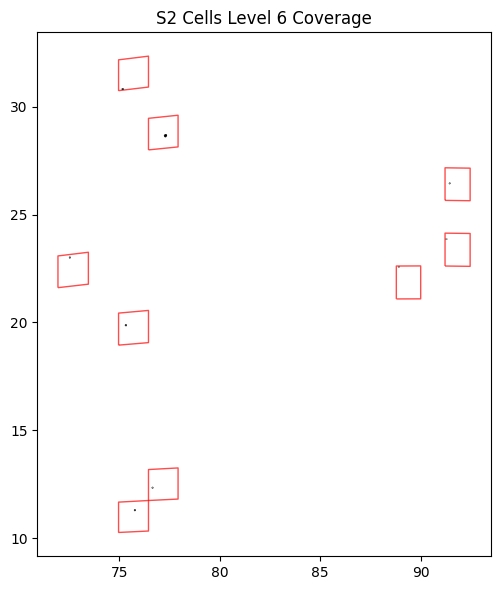

In [53]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [55]:
s2_gdf_join = s2_cells_gdf.sjoin(
    gdf[["Unique Shape ID", "geometry"]], how="inner", predicate="intersects"
).drop(columns="index_right").drop_duplicates()
s2_gdf_join

,s2_cell_id,geometry,Unique Shape ID
0,4110942034859130880,"POLYGON ((76.45631 27.99812, 77.92817 28.13705...",SHAPE_02
0,4110942034859130880,"POLYGON ((76.45631 27.99812, 77.92817 28.13705...",SHAPE_01
0,4110942034859130880,"POLYGON ((76.45631 27.99812, 77.92817 28.13705...",SHAPE_03
1,4300656169162113024,"POLYGON ((76.45631 11.74558, 77.92817 11.81246...",SHAPE_05
1,4300656169162113024,"POLYGON ((76.45631 11.74558, 77.92817 11.81246...",SHAPE_04
1,4300656169162113024,"POLYGON ((76.45631 11.74558, 77.92817 11.81246...",SHAPE_06
2,4298404369348427776,"POLYGON ((74.96764 10.26410, 76.45631 10.33079...",SHAPE_09
2,4298404369348427776,"POLYGON ((74.96764 10.26410, 76.45631 10.33079...",SHAPE_08
2,4298404369348427776,"POLYGON ((74.96764 10.26410, 76.45631 10.33079...",SHAPE_07
3,4114882684533080064,"POLYGON ((74.96764 30.74458, 76.45631 30.91143...",SHAPE_10


#### Download the S2 cells

In [56]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

File 4110942034859130880 already exists.
File 4300656169162113024 already exists.
File 4298404369348427776 already exists.
File 4114882684533080064 already exists.
File 4134022982949404672 already exists.
File 4313041068137381888 already exists.
File 3986530095153020928 already exists.
File 4179621929176530944 already exists.
File 3988781894966706176 already exists.


## 6. Load rooftops and match to areas

In [57]:
def get_matched_rooftop_centroids_from_s2_file(
    s2_cell_id: int, boundaries_gdf: gpd.GeoDataFrame
) -> gpd.GeoDataFrame:
    """
    Get rooftops from the S2 cell file that match the boundaries:
    1. loads the rooftops data for the specified S2 cell ID
    2. filters the rooftops to only those that intersect with the boundaries
    3. returns a GeoDataFrame of the matched rooftops centroids with unique IDs

    Parameters:
    - s2_cell_id (int): The S2 cell ID to filter rooftops for.
    - boundaries_gdf (gpd.GeoDataFrame): The GeoDataFrame containing the boundaries.
    """

    # load the rooftops data for the S2 cell
    s2_rooftops_path = RAW_DATA_DIR / "02. Rooftop Data" / f"{s2_cell_id}.parquet"
    s2_rooftops_gdf = gpd.read_parquet(s2_rooftops_path)

    # replace polygons with just the centroid of the rooftops
    s2_rooftop_centroids_gdf = s2_rooftops_gdf.set_geometry(
        s2_rooftops_gdf.geometry.centroid
    )

    # filter the boundaries dataset to only the shapes that overlap the S2 cell
    s2_cell_polygon = s2_cell_id_to_shape(s2_cell_id)
    boundaries_gdf_s2_overlap = boundaries_gdf[
        boundaries_gdf.intersects(s2_cell_polygon)
    ]

    # perform a spatial join to filter and add area metadata to the rooftops
    matched_rooftop_centroids_gdf = gpd.sjoin(
        s2_rooftop_centroids_gdf,
        boundaries_gdf_s2_overlap,
        how="inner",
        predicate="within",
    ).drop(columns=["index_right"])

    # add IDs to each rooftop
    matched_rooftop_centroids_gdf["s2_rooftop_id"] = create_ids(
        len(matched_rooftop_centroids_gdf), f"S2_{s2_cell_id}_ROOFTOP_"
    )

    return matched_rooftop_centroids_gdf

In [ ]:
try:
    # Get matched rooftops for each S2 cell
    matched_rooftop_centroids_gdf_list = []
    for s2_cell_id in tqdm(s2_cell_ids):
        matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
            s2_cell_id, gdf
        )
        matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
    matched_rooftop_centroids_gdf = pd.concat(
        matched_rooftop_centroids_gdf_list, ignore_index=True
    )

    # Save the matched rooftops data
    save_shapefiles(
        matched_rooftop_centroids_gdf,
        CLEANED_DATA_DIR / "01. Matched Rooftop Data" / "pilot_v2",
        "matched_rooftops",
        ["parquet"],
    )
except Exception as e:
    print(f"Error processing: {e}")

  0%|          | 0/9 [00:00<?, ?it/s]

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_5120/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_5120/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_5120/207331629.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_5120/207331629.py:21: UserWarning: 

In [59]:
matched_rooftop_centroids_gdf

,boundary_id,bf_source,confidence,area_in_meters,s2_id,country_iso,geometry,geohash,bbox,Unique Shape ID,s2_rooftop_id
0,56,google,0.7254,22.1628,4110942034859130880,IND,POINT (77.27732 28.62175),ttnfy6rt,"{'xmin': 77.2772847574922, 'ymin': 28.62172387...",SHAPE_02,S2_4110942034859130880_ROOFTOP_000001
1,56,google,0.8355,361.7931,4110942034859130880,IND,POINT (77.27658 28.62237),ttnfy6x1,"{'xmin': 77.2764444422339, 'ymin': 28.62224674...",SHAPE_02,S2_4110942034859130880_ROOFTOP_000002
2,56,google,0.7451,14.4074,4110942034859130880,IND,POINT (77.27737 28.62245),ttnfy6x9,"{'xmin': 77.2773452197574, 'ymin': 28.62242177...",SHAPE_02,S2_4110942034859130880_ROOFTOP_000003
3,56,google,0.7765,45.4175,4110942034859130880,IND,POINT (77.27747 28.62242),ttnfy6x9,"{'xmin': 77.2774170539245, 'ymin': 28.62237506...",SHAPE_02,S2_4110942034859130880_ROOFTOP_000004
4,56,google,0.7520,15.7805,4110942034859130880,IND,POINT (77.27778 28.62223),ttnfy6xb,"{'xmin': 77.2777574206892, 'ymin': 28.62220538...",SHAPE_02,S2_4110942034859130880_ROOFTOP_000005
...,...,...,...,...,...,...,...,...,...,...,...
254458,56,google,0.8361,46.1492,3988781894966706176,IND,POINT (91.44475 26.45695),wh9n8bk4,"{'xmin': 91.4447211257358, 'ymin': 26.45690753...",SHAPE_25,S2_3988781894966706176_ROOFTOP_7839
254459,56,google,0.8328,24.1154,3988781894966706176,IND,POINT (91.44511 26.45689),wh9n8bk6,"{'xmin': 91.4450846871399, 'ymin': 26.45686494...",SHAPE_25,S2_3988781894966706176_ROOFTOP_7840
254460,56,google,0.9138,219.3041,3988781894966706176,IND,POINT (91.44570 26.45678),wh9n8bk9,"{'xmin': 91.4456050907305, 'ymin': 26.45672897...",SHAPE_25,S2_3988781894966706176_ROOFTOP_7841
254461,56,google,0.7967,105.0942,3988781894966706176,IND,POINT (91.44628 26.45649),wh9n8bm0,"{'xmin': 91.4462054091157, 'ymin': 26.45642817...",SHAPE_25,S2_3988781894966706176_ROOFTOP_7842


<Axes: >

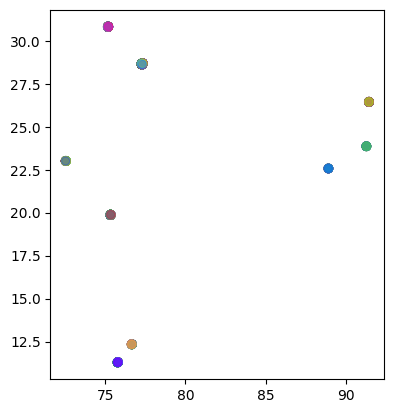

In [60]:
matched_rooftop_centroids_gdf.sample(1000).plot(
    cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
)

## 7. Load matched rooftops

In [64]:
matched_rooftops_gdf = gpd.read_parquet(
    CLEANED_DATA_DIR / "01. Matched Rooftop Data" / "pilot_v2" / "matched_rooftops.parquet"
)

In [66]:
matched_rooftops_gdf

,boundary_id,bf_source,confidence,area_in_meters,s2_id,country_iso,geometry,geohash,bbox,Unique Shape ID,s2_rooftop_id
0,56,google,0.7254,22.1628,4110942034859130880,IND,POINT (77.27732 28.62175),ttnfy6rt,"{'xmax': 77.2773607427648, 'xmin': 77.27728475...",SHAPE_02,S2_4110942034859130880_ROOFTOP_000001
1,56,google,0.8355,361.7931,4110942034859130880,IND,POINT (77.27658 28.62237),ttnfy6x1,"{'xmax': 77.2767065510336, 'xmin': 77.27644444...",SHAPE_02,S2_4110942034859130880_ROOFTOP_000002
2,56,google,0.7451,14.4074,4110942034859130880,IND,POINT (77.27737 28.62245),ttnfy6x9,"{'xmax': 77.2773978322357, 'xmin': 77.27734521...",SHAPE_02,S2_4110942034859130880_ROOFTOP_000003
3,56,google,0.7765,45.4175,4110942034859130880,IND,POINT (77.27747 28.62242),ttnfy6x9,"{'xmax': 77.2775136758006, 'xmin': 77.27741705...",SHAPE_02,S2_4110942034859130880_ROOFTOP_000004
4,56,google,0.7520,15.7805,4110942034859130880,IND,POINT (77.27778 28.62223),ttnfy6xb,"{'xmax': 77.2778124843069, 'xmin': 77.27775742...",SHAPE_02,S2_4110942034859130880_ROOFTOP_000005
...,...,...,...,...,...,...,...,...,...,...,...
254458,56,google,0.8361,46.1492,3988781894966706176,IND,POINT (91.44475 26.45695),wh9n8bk4,"{'xmax': 91.44478162423572, 'xmin': 91.4447211...",SHAPE_25,S2_3988781894966706176_ROOFTOP_7839
254459,56,google,0.8328,24.1154,3988781894966706176,IND,POINT (91.44511 26.45689),wh9n8bk6,"{'xmax': 91.4451401314101, 'xmin': 91.44508468...",SHAPE_25,S2_3988781894966706176_ROOFTOP_7840
254460,56,google,0.9138,219.3041,3988781894966706176,IND,POINT (91.44570 26.45678),wh9n8bk9,"{'xmax': 91.4458031595908, 'xmin': 91.44560509...",SHAPE_25,S2_3988781894966706176_ROOFTOP_7841
254461,56,google,0.7967,105.0942,3988781894966706176,IND,POINT (91.44628 26.45649),wh9n8bm0,"{'xmax': 91.4463605607651, 'xmin': 91.44620540...",SHAPE_25,S2_3988781894966706176_ROOFTOP_7842


## 8. Sample rooftops

### Do the sampling

In [94]:
# Define the base number of rooftops per shape
ROOFTOPS_PER_SHAPE = 20

sampled_rooftops = matched_rooftops_gdf.groupby(
    "Unique Shape ID", group_keys=False
).apply(
    lambda x: x.sample(
        n=ROOFTOPS_PER_SHAPE,
        random_state=42
    )
)

In [95]:
len(sampled_rooftops)/ROOFTOPS_PER_SHAPE

27.0

<Axes: >

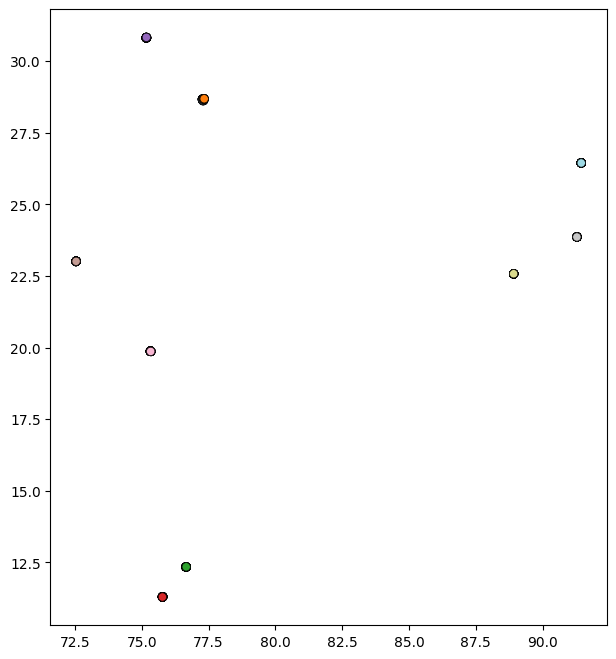

In [96]:
sampled_rooftops.plot(
    figsize=(8, 8),
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

### Add sample-level rooftop numbering ID columns

In [97]:
# Rooftop number within each shape
sampled_rooftops["Rooftop ID Per Shape"] = (
    sampled_rooftops.groupby("Unique Shape ID").cumcount() + 1
)

sampled_rooftops["Unique Rooftop ID"] = sampled_rooftops.apply(
    lambda row: f"{row['Unique Shape ID']}_ROOFTOP_{row['Rooftop ID Per Shape']}",
    axis=1,
)

In [98]:
sampled_rooftops

,boundary_id,bf_source,confidence,area_in_meters,s2_id,country_iso,geometry,geohash,bbox,Unique Shape ID,s2_rooftop_id,Rooftop ID Per Shape,Unique Rooftop ID
95763,56,google,0.7063,114.1021,4110942034859130880,IND,POINT (77.28948 28.67153),ttngng2r,"{'xmax': 77.2895730174797, 'xmin': 77.28939466...",SHAPE_01,S2_4110942034859130880_ROOFTOP_095764,1,SHAPE_01_ROOFTOP_1
76260,56,google,0.7488,43.5384,4110942034859130880,IND,POINT (77.26417 28.66700),ttngn4wj,"{'xmax': 77.2642159806525, 'xmin': 77.26411953...",SHAPE_01,S2_4110942034859130880_ROOFTOP_076261,2,SHAPE_01_ROOFTOP_2
84702,56,google,0.6868,23.3744,4110942034859130880,IND,POINT (77.27353 28.67380),ttngn7uu,"{'xmax': 77.27356262559012, 'xmin': 77.2735020...",SHAPE_01,S2_4110942034859130880_ROOFTOP_084703,3,SHAPE_01_ROOFTOP_3
93974,56,google,0.7074,17.5531,4110942034859130880,IND,POINT (77.28628 28.66961),ttngnenh,"{'xmax': 77.286305144229, 'xmin': 77.286262055...",SHAPE_01,S2_4110942034859130880_ROOFTOP_093975,4,SHAPE_01_ROOFTOP_4
76406,56,google,0.7606,120.9681,4110942034859130880,IND,POINT (77.26583 28.66713),ttngn4xq,"{'xmax': 77.2659062797154, 'xmin': 77.26575797...",SHAPE_01,S2_4110942034859130880_ROOFTOP_076407,5,SHAPE_01_ROOFTOP_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249187,56,google,0.6849,20.4992,3988781894966706176,IND,POINT (91.43550 26.44679),wh9n2wmr,"{'xmax': 91.4355157984197, 'xmin': 91.43548593...",SHAPE_27,S2_3988781894966706176_ROOFTOP_2568,16,SHAPE_27_ROOFTOP_16
248965,56,google,0.7014,39.2353,3988781894966706176,IND,POINT (91.43508 26.44430),wh9n2whc,"{'xmax': 91.4351297245567, 'xmin': 91.43503262...",SHAPE_27,S2_3988781894966706176_ROOFTOP_2346,17,SHAPE_27_ROOFTOP_17
247396,56,google,0.7852,223.6625,3988781894966706176,IND,POINT (91.43443 26.44388),wh9n2tuw,"{'xmax': 91.4344744742444, 'xmin': 91.43438550...",SHAPE_27,S2_3988781894966706176_ROOFTOP_0777,18,SHAPE_27_ROOFTOP_18
250184,56,google,0.8637,137.1705,3988781894966706176,IND,POINT (91.44090 26.44599),wh9n2y35,"{'xmax': 91.4409927800152, 'xmin': 91.44081607...",SHAPE_27,S2_3988781894966706176_ROOFTOP_3565,19,SHAPE_27_ROOFTOP_19


### Add gmap link

In [99]:
sampled_rooftops["latitude"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude",
    lon_name="longitude",
)

### Select only useful columns

In [100]:
sampled_rooftops.columns

Index(['boundary_id', 'bf_source', 'confidence', 'area_in_meters', 's2_id',
       'country_iso', 'geometry', 'geohash', 'bbox', 'Unique Shape ID',
       's2_rooftop_id', 'Rooftop ID Per Shape', 'Unique Rooftop ID',
       'latitude', 'longitude', 'gmap_link'],
      dtype='object')

In [107]:
chosen_cols = [
    "Unique Rooftop ID",
    "Unique Shape ID",
    "Rooftop ID Per Shape",
    "latitude",
    "longitude",
    "gmap_link",
    "geometry",
    # ## rooftop info
    # "boundary_id",
    # "bf_source",
    # "confidence",
    # "area_in_meters",
    # "s2_id",
    # "country_iso",
    # "geohash",
    # "bbox",
]

In [108]:
sampled_rooftops_organised_gdf = sampled_rooftops[chosen_cols]

In [109]:
sampled_rooftops_organised_gdf

,Unique Rooftop ID,Unique Shape ID,Rooftop ID Per Shape,latitude,longitude,gmap_link,geometry
95763,SHAPE_01_ROOFTOP_1,SHAPE_01,1,28.671526,77.289483,https://www.google.com/maps/search/?api=1&quer...,POINT (77.28948 28.67153)
76260,SHAPE_01_ROOFTOP_2,SHAPE_01,2,28.667005,77.264168,https://www.google.com/maps/search/?api=1&quer...,POINT (77.26417 28.66700)
84702,SHAPE_01_ROOFTOP_3,SHAPE_01,3,28.673796,77.273532,https://www.google.com/maps/search/?api=1&quer...,POINT (77.27353 28.67380)
93974,SHAPE_01_ROOFTOP_4,SHAPE_01,4,28.669607,77.286284,https://www.google.com/maps/search/?api=1&quer...,POINT (77.28628 28.66961)
76406,SHAPE_01_ROOFTOP_5,SHAPE_01,5,28.667130,77.265832,https://www.google.com/maps/search/?api=1&quer...,POINT (77.26583 28.66713)
...,...,...,...,...,...,...,...
249187,SHAPE_27_ROOFTOP_16,SHAPE_27,16,26.446791,91.435501,https://www.google.com/maps/search/?api=1&quer...,POINT (91.43550 26.44679)
248965,SHAPE_27_ROOFTOP_17,SHAPE_27,17,26.444302,91.435081,https://www.google.com/maps/search/?api=1&quer...,POINT (91.43508 26.44430)
247396,SHAPE_27_ROOFTOP_18,SHAPE_27,18,26.443880,91.434431,https://www.google.com/maps/search/?api=1&quer...,POINT (91.43443 26.44388)
250184,SHAPE_27_ROOFTOP_19,SHAPE_27,19,26.445989,91.440904,https://www.google.com/maps/search/?api=1&quer...,POINT (91.44090 26.44599)


### Save sampled data (original rooftop pins)

In [110]:
save_shapefiles(
    sampled_rooftops_organised_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Lossy conversion occurred when trying to set 64 bit integer field from a real value.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.671526169615195,77.28948334537085' of field sampled_rooftops_centroids_original.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.66700467970472,77.26416775785552' of field sampled_rooftops_centroids_original.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/se

## 9. Snap points to road

### Functions

In [111]:
from shapely import Point
import requests
from concurrent.futures import ThreadPoolExecutor


def get_nearest_point_on_road(point: Point, api_key: str) -> Point | None:
    """
    Retrieves the nearest point on the road for a given point using the Google Roads API.

    Args:
        point (Point): The point for which to find the nearest point on the road.
        api_key (str): Your Google Roads API key.

    Returns:
        Point: The nearest point on the road, or None if no point is found.

    """
    url = f"https://roads.googleapis.com/v1/snapToRoads?path={point.y},{point.x}&key={api_key}"
    response = requests.get(url)
    snapped_point = response.json().get("snappedPoints", [{}])[0].get("location")
    return (
        Point(snapped_point["longitude"], snapped_point["latitude"])
        if snapped_point
        else None
    )

def snap_point_to_road(args):
    """Helper function to snap a point to the nearest road."""
    idx, point, api_key = args
    try:
        snapped_point = get_nearest_point_on_road(point, api_key)
        return idx, snapped_point
    except Exception as e:
        print(f"Error snapping point at index {idx}: {str(e)}")
        return idx, None

def snap_points_to_roads_parallel(gdf, api_key, max_workers=10) -> gpd.GeoSeries:
    """
    Snap all points in a GeoDataFrame to the nearest road using parallel processing.
    
    Args:
        gdf: GeoDataFrame containing point geometries
        api_key: Google Roads API key
        max_workers: Number of parallel workers
        
    Returns:
        GeoSeries with snapped geometries
    """
    # Prepare arguments for parallel processing
    args_list = [(idx, point, api_key) for idx, point in enumerate(gdf.geometry)]
    
    # Initialize results dictionary
    snapped_points = {}
    
    # Process in parallel with progress bar
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Submit all tasks and track with tqdm
        results = list(tqdm(
            executor.map(snap_point_to_road, args_list), 
            total=len(args_list),
            desc="Snapping points to roads"
        ))
    
    # Process results
    for idx, snapped_point in results:
        snapped_points[idx] = snapped_point
    snapped_points_series = gpd.GeoSeries(snapped_points)

    return snapped_points_series

### Run

In [113]:
# load API key
import yaml
with open('../secrets/api_keys.yaml', 'r') as f:
    config = yaml.safe_load(f)
    api_key = config['GOOGLE_ROADS_API_KEY']

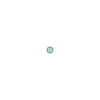

In [115]:
# test
get_nearest_point_on_road(
    sampled_rooftops_organised_gdf.geometry.iloc[0], api_key
)

In [116]:
len(sampled_rooftops_organised_gdf)

540

#### Snap points to road

In [117]:
snapped_points_series = snap_points_to_roads_parallel(
    sampled_rooftops_organised_gdf, 
    api_key,
    max_workers=12
)
# took 1min for 3,200 points

Snapping points to roads:   0%|          | 0/540 [00:00<?, ?it/s]

In [118]:
sampled_rooftops_snapped_gdf = sampled_rooftops_organised_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = list(snapped_points_series)

In [119]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

Geometry Type
Snapped to Road    537
Original             3
Name: count, dtype: int64

#### Replace geometry to snapped one (missing filled in with original)

In [120]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf.loc[
    sampled_rooftops_snapped_gdf["geometry"].isna(), 
    "geometry"] = sampled_rooftops_snapped_gdf.loc[
        sampled_rooftops_snapped_gdf["geometry"].isna(),
        "geometry_original"
]

In [121]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

0

#### Update lat, lon, gmap_link

In [122]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.rename(
    columns={
        "latitude": "latitude_original",
        "longitude": "longitude_original",
        "gmap_link": "gmap_link_original",
    },
)

In [123]:
sampled_rooftops_snapped_gdf["latitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.y
)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Reorganise

In [124]:
sampled_rooftops_snapped_gdf.columns

Index(['Unique Rooftop ID', 'Unique Shape ID', 'Rooftop ID Per Shape',
       'latitude_original', 'longitude_original', 'gmap_link_original',
       'geometry', 'Geometry Type', 'geometry_original', 'latitude',
       'longitude', 'gmap_link'],
      dtype='object')

In [126]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf[
    [
        "Unique Rooftop ID",
        "Unique Shape ID",
        "Rooftop ID Per Shape",
        "Geometry Type",
        "latitude",
        "longitude",
        "gmap_link",
        "latitude_original",
        "longitude_original",
        "gmap_link_original",
        "geometry_original",
        "geometry",
    ]
]

#### Make lines between original and snapped points

In [128]:
from shapely.geometry import LineString

In [129]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

In [130]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

0

#### Save new files: snapped points, snapped lines

In [133]:
# Save snapped points
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Lossy conversion occurred when trying to set 64 bit integer field from a real value.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.67158454316796,77.28953975280173' of field sampled_rooftops_snapped_points.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.671526169615195,77.28948334537085' of field sampled_rooftops_snapped_points.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/s

In [134]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
save_shapefiles(
    sampled_rooftops_line_gdf.drop(
    columns=["geometry_line", "geometry_original"]
),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Lossy conversion occurred when trying to set 64 bit integer field from a real value.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.67158454316796,77.28953975280173' of field sampled_rooftops_snapped_lines.latitude parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=28.671526169615195,77.28948334537085' of field sampled_rooftops_snapped_lines.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/3.12.9/envs/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/sea